In [2]:
from matplotlib import pyplot as plt
from scipy.spatial.distance import cdist
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

import torch
import numpy as np
from copy import deepcopy
from functools import reduce

from torch import nn
import pickle as pkl
from umap import UMAP

from model import DNN
from run_sim import Config, run_sim, create_data, train_model
from utils import cosine_similarity, get_r_2, vector_angle, flatten_list
from tqdm import tqdm
from utils import alignment_score, calc_PR, calc_NC1
import matplotlib as mpl
from functools import reduce



In [3]:
def calc_h_var(G, D, N, L, sig_X):
    return G**(2*L)*(2*D*sig_X)/(D+N)

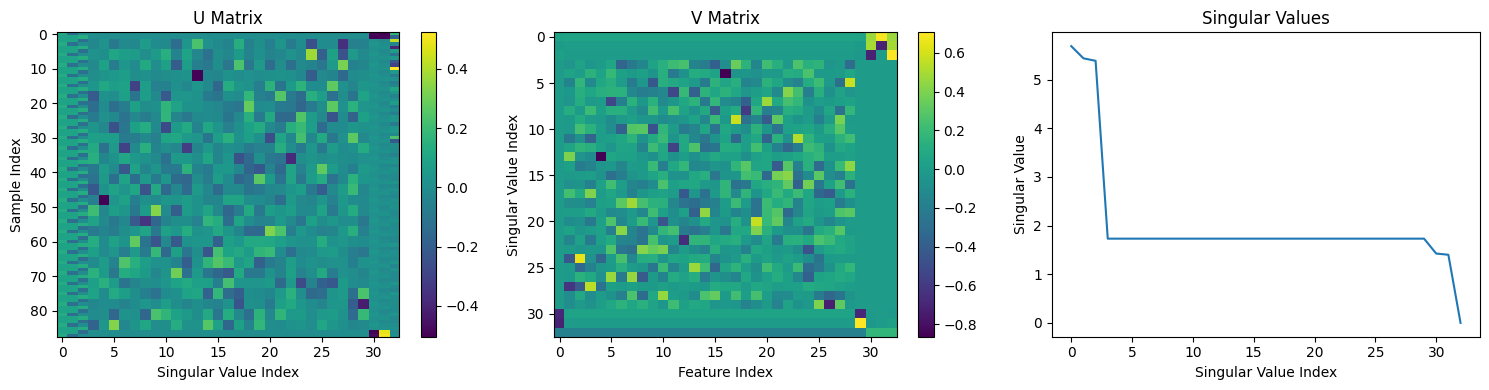

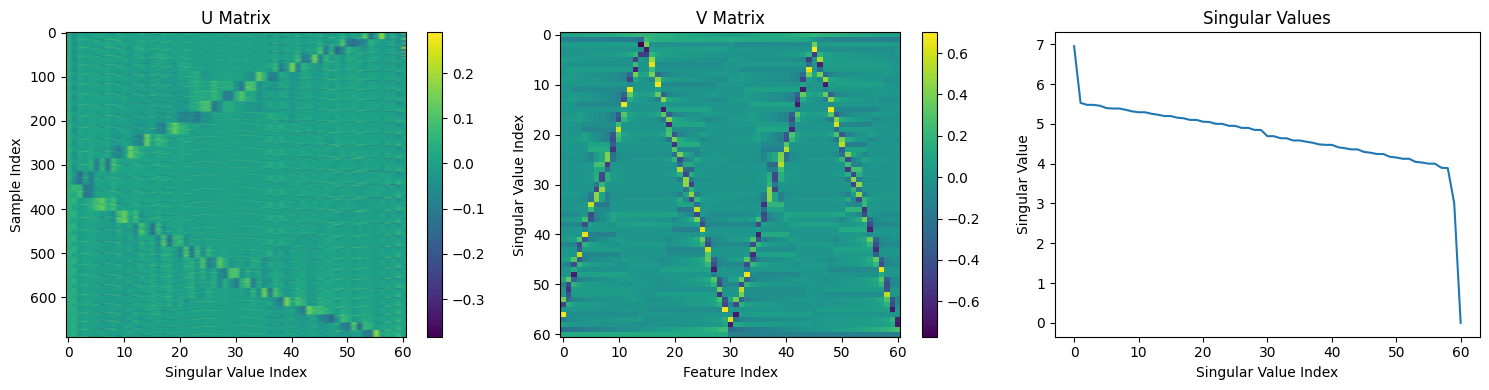

In [ ]:
C = Config()

C.length_corridors = [30]
for max_move in [1, 15]:
    C.max_move = max_move

    X, y, corridor, loc_X, loc_y, action_taken, dim_l, input_size, output_size, n_actions = create_data(C)

    X_np = X
    y_np = y

    U, S, V = np.linalg.svd(X_np, full_matrices=False)
    # Plot U and V matrices
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Plot U matrix
    im1 = axes[0].imshow(U, cmap='viridis', aspect='auto')
    axes[0].set_title('U Matrix')
    axes[0].set_xlabel('Singular Value Index')
    axes[0].set_ylabel('Sample Index')
    plt.colorbar(im1, ax=axes[0])

    # Plot V matrix
    im2 = axes[1].imshow(V, cmap='viridis', aspect='auto')
    axes[1].set_title('V Matrix')
    axes[1].set_xlabel('Feature Index')
    axes[1].set_ylabel('Singular Value Index')
    plt.colorbar(im2, ax=axes[1])

    axes[2].plot(S)
    axes[2].set_title('Singular Values')
    axes[2].set_xlabel('Singular Value Index')
    axes[2].set_ylabel('Singular Value')

    plt.tight_layout()
    plt.show()
